Run start: 2026-04-06 15:27:42


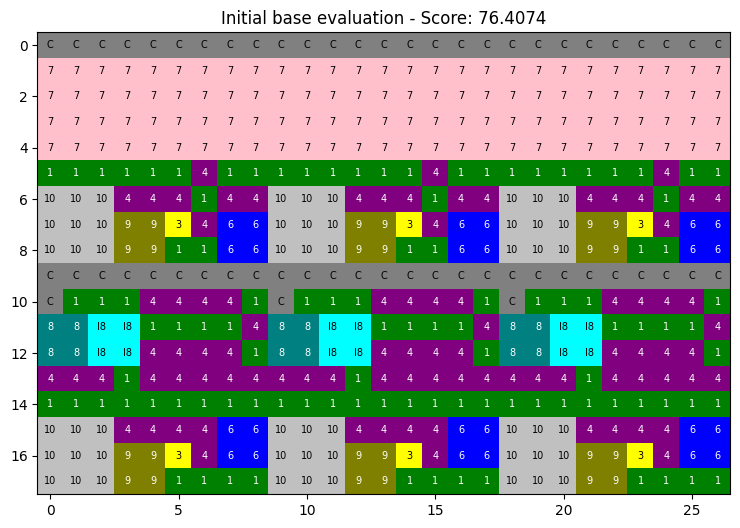


--- Starting ALNS trifecta (27x18) ---
ALNS start time: 2026-04-06 15:27:42
Improvement [block] @ 2026-04-06 15:28:17 | +0.58 min | 76.6296 (NV: 40) (w: 0.61)
Improvement [random] @ 2026-04-06 15:29:10 | +1.47 min | 76.7037 (NV: 27) (w: 0.60)
ALNS end time: 2026-04-06 15:30:14 | elapsed=2.53 min


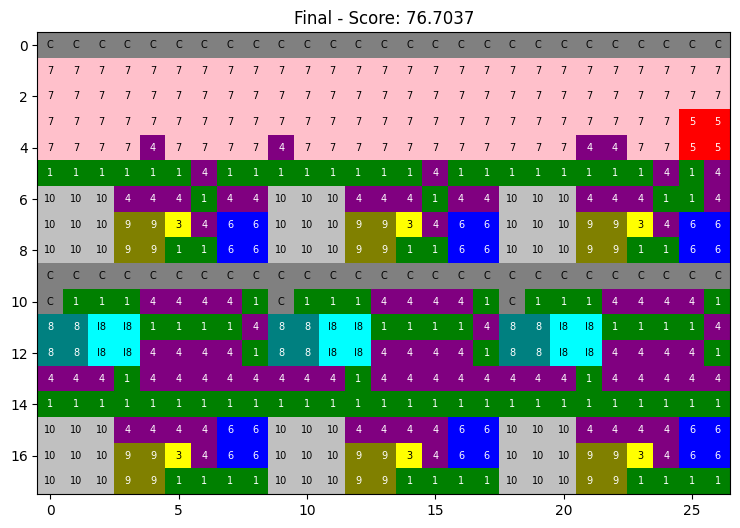

Run end: 2026-04-06 15:30:15 | elapsed=2.55 min

FINAL PATTERN EXTRACTION

--- PYTHON LIST FORMAT (copyable) ---
final_pattern = [
    ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C'],
    ['7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7'],
    ['7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7'],
    ['7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '5', '5'],
    ['7', '7', '7', '7', '4', '7', '7', '7', '7', '4', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '7', '4', '4', '7', '7', '5', '5'],
    ['1', '1', '1', '1', '1', '1', '4', '1', '1', '1', '1', '1', '1', '1', '1', '4', '1', '1', '1', '1', '1', '1', '1', '1', '4', '1', '4'],
    ['10', '10', '10', 

In [2]:
from ortools.sat.python import cp_model
import itertools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from numba import njit
import time
import random
from datetime import datetime
@njit(fastmath=True)
def get_manhattan_neighbors_numba(i, j, PH, PW):
    neighbors = []
    for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        ni = (i + di) % PH
        nj = (j + dj) % PW
        neighbors.append((ni, nj))
    return neighbors

@njit(fastmath=True)
def get_block_neighbors_numba(anchor_i, anchor_j, block_h, block_w, radius, PH, PW):
    is_block = np.zeros((PH, PW), dtype=np.bool_)
    for di in range(block_h):
        for dj in range(block_w):
            is_block[(anchor_i + di) % PH, (anchor_j + dj) % PW] = True
    neighbors = []
    visited = np.zeros((PH, PW), dtype=np.bool_)
    for di in range(block_h):
        for dj in range(block_w):
            ci = (anchor_i + di) % PH
            cj = (anchor_j + dj) % PW
            for ri in range(-radius, radius + 1):
                for rj in range(-radius, radius + 1):
                    if ri == 0 and rj == 0: continue
                    ni = (ci + ri) % PH
                    nj = (cj + rj) % PW
                    if not is_block[ni, nj] and not visited[ni, nj]:
                        visited[ni, nj] = True
                        neighbors.append((ni, nj))
    return neighbors

def optimize_pattern_multisize(PW, PH, type_catalog, productions, time_limit_s=60, initial_hint_pattern=None, is_lns_step=False, fixed_cells_mask=None, l_stacks=1, d_stacks=1, min_score_threshold=None):
    model = cp_model.CpModel()
    TPW, TPH = PW * l_stacks, PH * d_stacks
    grid_size = TPW * TPH

    type_defs = {k: v.copy() for k, v in type_catalog.items()}
    type_defs['C'] = {"size": (1, 1)}
    for t_data in type_defs.values():
        t_data.setdefault("rules", []); t_data.setdefault("size", (1, 1))
        t_data.setdefault("self_improvements", [])
    all_type_names = list(type_defs.keys())

    is_anchor = {}
    occupies = {}
    for i, j, t in itertools.product(range(TPH), range(TPW), all_type_names):
        is_anchor[(i, j, t)] = model.NewBoolVar(f"a_{i}_{j}_{t}")
        occupies[(i, j, t)] = model.NewBoolVar(f"o_{i}_{j}_{t}")

    if initial_hint_pattern:
        if not is_lns_step:
            for r in range(TPH):
                for c in range(TPW):
                    t_val = initial_hint_pattern[r][c]
                    if t_val in all_type_names:
                        model.Add(occupies[(r, c, t_val)] == 1)
        else:
            for r in range(TPH):
                for c in range(TPW):
                    t_val = initial_hint_pattern[r][c]
                    if t_val in all_type_names:
                        if fixed_cells_mask is not None and (r, c) in fixed_cells_mask:
                            model.Add(occupies[(r, c, t_val)] == 1)
                        else:
                            model.AddHint(occupies[(r, c, t_val)], 1)

    for i, j in itertools.product(range(TPH), range(TPW)):
        model.AddExactlyOne(occupies[(i, j, t)] for t in all_type_names)
        for t, t_data in type_defs.items():
            th, tw = t_data["size"]
            anchors = [is_anchor[((i-di)%TPH, (j-dj)%TPW, t)] for di, dj in itertools.product(range(th), range(tw))]
            model.AddBoolOr(anchors).OnlyEnforceIf(occupies[(i, j, t)])
            for a_var in anchors: model.AddImplication(a_var, occupies[(i, j, t)])

    for t, t_data in type_defs.items():
        th, tw = t_data["size"]
        if th > 1 or tw > 1:
            for i, j in itertools.product(range(TPH), range(TPW)):
                for di, dj in itertools.product(range(th), range(tw)):
                    if di == 0 and dj == 0: continue
                    r, c = (i + di) % TPH, (j + dj) % TPW
                    model.Add(is_anchor[(r, c, t)] == 0).OnlyEnforceIf(is_anchor[(i, j, t)])

    for j in range(TPW): 
        model.Add(occupies[(0, j, 'C')] == 1)
        model.Add(occupies[(9, j, 'C')] == 1)

    connectivity_roots = {(0, 0), (9, 0)}
    rank = {(i,j): model.NewIntVar(0, grid_size, f"r_{i}_{j}") for i,j in itertools.product(range(TPH), range(TPW))}
    
    for i,j in itertools.product(range(TPH), range(TPW)):
        if (i, j) in connectivity_roots:
            model.Add(rank[(i,j)] == 0)
        else:
            model.Add(rank[(i,j)] == grid_size).OnlyEnforceIf(occupies[(i,j,'C')].Not())
            parents = []
            for ni, nj in get_manhattan_neighbors_numba(i, j, TPH, TPW):
                p = model.NewBoolVar(f"p_{i}_{j}_{ni}_{nj}")
                model.Add(rank[ni,nj] < rank[i,j]).OnlyEnforceIf(p)
                model.Add(occupies[(ni,nj,'C')] == 1).OnlyEnforceIf(p)
                parents.append(p)
            model.Add(sum(parents) >= 1).OnlyEnforceIf(occupies[(i,j,'C')])

    obj_vars = []
    for i, j, t in itertools.product(range(TPH), range(TPW), all_type_names):
        anchor_var = is_anchor[(i, j, t)]
        t_data, base_prod = type_defs[t], productions.get(t, 0)
        for r in t_data.get("rules", []):
            ns = get_block_neighbors_numba(i, j, t_data["size"][0], t_data["size"][1], r["radio"], TPH, TPW)
            cnt = sum(occupies[(ni, nj, r["tipo"])] for ni, nj in ns)
            if "min" in r: model.Add(cnt >= r["min"]).OnlyEnforceIf(anchor_var)
            if "max" in r: model.Add(cnt <= r["max"]).OnlyEnforceIf(anchor_var)
        
        possible_p = {0, base_prod}
        for ru in t_data.get("self_improvements", []): possible_p.add(ru["production"])
        v = model.NewIntVarFromDomain(cp_model.Domain.FromValues(list(possible_p)), f"p_{i}_{j}_{t}")
        model.Add(v == 0).OnlyEnforceIf(anchor_var.Not())
        
        improves = []
        for ru in t_data.get("self_improvements", []):
            ns = get_block_neighbors_numba(i, j, t_data["size"][0], t_data["size"][1], ru["condition"]["radio"], TPH, TPW)
            is_imp = model.NewBoolVar(f"im_{i}_{j}_{t}")
            model.Add(sum(occupies[(ni, nj, ru["condition"]["tipo"])] for ni, nj in ns) >= ru["condition"]["min"]).OnlyEnforceIf(is_imp)
            model.Add(sum(occupies[(ni, nj, ru["condition"]["tipo"])] for ni, nj in ns) < ru["condition"]["min"]).OnlyEnforceIf(is_imp.Not())
            model.Add(v == ru["production"]).OnlyEnforceIf([anchor_var, is_imp])
            improves.append(is_imp)
            
        if improves:
            any_i = model.NewBoolVar(f"ai_{i}_{j}_{t}")
            model.AddBoolOr(improves).OnlyEnforceIf(any_i)
            model.Add(v == base_prod).OnlyEnforceIf([anchor_var, any_i.Not()])
        else: model.Add(v == base_prod).OnlyEnforceIf(anchor_var)
        obj_vars.append(v)

    total_score = sum(obj_vars)
    if min_score_threshold is not None: model.Add(total_score > int(min_score_threshold))
    model.Maximize(total_score)
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit_s
    st = solver.Solve(model)
    if st in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        pattern = [[None]*TPW for _ in range(TPH)]
        for i,j in itertools.product(range(TPH), range(TPW)):
            for t in all_type_names:
                if solver.Value(occupies[(i,j,t)]): pattern[i][j] = t; break
        return pattern, solver.ObjectiveValue() / grid_size
    return None, 0

def alns_trifecta_loop(PW, PH, type_defs, productions, initial_pat, initial_sc, total_time=60, l_stacks=1, d_stacks=1, run_start_perf=None, run_start_wall=None):
    TPW, TPH = PW * l_stacks, PH * d_stacks
    if run_start_perf is None:
        run_start_perf = time.perf_counter()
    if run_start_wall is None:
        run_start_wall = datetime.now()
    print(f"\n--- Starting ALNS trifecta ({TPW}x{TPH}) ---")
    print(f"ALNS start time: {run_start_wall:%Y-%m-%d %H:%M:%S}")
    curr_pat, curr_sc = initial_pat, initial_sc
    
    ops = ["random", "block", "ivrg_structural"]
    weights = {op: 1.0 for op in ops}
    nv = 40
    start_t = time.time()
    
    while time.time() - start_t < total_time:
        op = random.choices(ops, weights=[weights[o] for o in ops])[0]
        relaxed = set()
        if op == "random":
            all_cells = [(r, c) for r, c in itertools.product(range(TPH), range(TPW))]
            relaxed = set(random.sample(all_cells, min(nv, len(all_cells))))
        elif op == "block":
            sz = int(np.sqrt(nv))
            rs, cs = random.randint(0, TPH-1), random.randint(0, TPW-1)
            for i, j in itertools.product(range(sz), range(sz)): relaxed.add(((rs+i)%TPH, (cs+j)%TPW))
        elif op == "ivrg_structural":
            seed = (random.randint(0, TPH-1), random.randint(0, TPW-1))
            relaxed.add(seed); cand = [seed]
            while len(relaxed) < nv and cand:
                cr, cc = cand.pop(random.randint(0, len(cand)-1))
                for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                    nr, nc = (cr+dr)%TPH, (cc+dc)%TPW
                    if (nr, nc) not in relaxed:
                        relaxed.add((nr, nc)); cand.append((nr, nc))
                        if len(relaxed) >= nv: break
                if len(relaxed) >= nv: break

        fixed = {(r, c) for r, c in itertools.product(range(TPH), range(TPW)) if (r, c) not in relaxed}
        grid_size = TPW * TPH
        
        iter_start = time.time()
        new_p, new_s = optimize_pattern_multisize(PW, PH, type_defs, productions, time_limit_s=30, 
                                                 initial_hint_pattern=curr_pat, is_lns_step=True,
                                                 fixed_cells_mask=fixed, l_stacks=l_stacks, d_stacks=d_stacks,
                                                 min_score_threshold=curr_sc * grid_size)
        duration = max(0.1, time.time() - iter_start)

        if new_p and new_s > curr_sc:
            efficiency = (new_s - curr_sc) / duration
            weights[op] = weights[op] * 0.6 + efficiency * 0.4
            
            curr_pat, curr_sc = new_p, new_s
            elapsed_min = (time.perf_counter() - run_start_perf) / 60.0
            print(f"Improvement [{op}] @ {datetime.now():%Y-%m-%d %H:%M:%S} | +{elapsed_min:.2f} min | {curr_sc:.4f} (NV: {nv}) (w: {weights[op]:.2f})")
            nv = max(20, nv - 15)
        else:
            nv = min(TPH * TPW // 3, nv + 1)
            weights[op] = max(0.1, weights[op] * 0.9)
            
    total_elapsed_min = (time.perf_counter() - run_start_perf) / 60.0
    print(f"ALNS end time: {datetime.now():%Y-%m-%d %H:%M:%S} | elapsed={total_elapsed_min:.2f} min")
    return curr_pat, curr_sc

def visualize_grid(pattern, title, score, color_map):
    H, W = len(pattern), len(pattern[0])
    unique_types = sorted(list(color_map.keys()))
    numeric = np.array([[unique_types.index(c) for c in r] for r in pattern])
    cmap = mcolors.ListedColormap([color_map[t] for t in unique_types])
    fig, ax = plt.subplots(figsize=(W/3, H/3)) 
    ax.imshow(numeric, cmap=cmap)
    for i, j in itertools.product(range(H), range(W)):
        ax.text(j, i, pattern[i][j], ha="center", va="center", fontsize=7, 
                color="white" if np.mean(cmap(numeric[i,j])[:3])<0.5 else "black")
    plt.title(f"{title} - Score: {score:.4f}"); plt.show()


DEFAULT_INITIAL_CP_TIME_S = 15
DEFAULT_ALNS_TIME_S = 120
DEFAULT_EXPORT_FILENAME = "patron_clean.csv"


def build_demo_inputs():
    """Return the demo configuration used by the notebook and script."""
    type_catalog = {
        '1': {"size": (1, 1), "rules": [{"radio": 5, "tipo": "C", "min": 1}], "self_improvements": [{"condition": {"tipo": "2", "min": 1, "radio": 2}, "production": 16}]},
        '2': {"size": (1, 1), "rules": [{"radio": 5, "tipo": "C", "min": 1}]},
        '3': {"size": (1, 1), "rules": [{"radio": 5, "tipo": "3", "max": 0}, {"radio": 3, "tipo": "1", "min": 12}, {"radio": 3, "tipo": "C", "min": 1}]},
        '4': {"size": (1, 1), "rules": [{"radio": 1, "tipo": "4", "max": 5}, {"radio": 1, "tipo": "1", "min": 3}]},
        '5': {"size": (2, 2), "rules": [{"radio": 8, "tipo": "5", "max": 0}, {"radio": 5, "tipo": "4", "min": 4}]},
        '6': {"size": (2, 2), "rules": [{"radio": 6, "tipo": "6", "max": 0}, {"radio": 6, "tipo": "3", "min": 2}, {"radio": 3, "tipo": "C", "min": 1}], "self_improvements": [{"condition": {"tipo": "I8", "min": 6, "radio": 4}, "production": 400}]},
        '7': {"size": (1, 1), "rules": [{"radio": 6, "tipo": "8", "max": 0}, {"radio": 6, "tipo": "I8", "max": 0}, {"radio": 6, "tipo": "3", "min": 1}, {"radio": 5, "tipo": "C", "min": 1}]},
        '8': {"size": (2, 2), "rules": [{"radio": 6, "tipo": "8", "max": 0}, {"radio": 4, "tipo": "1", "min": 20}, {"radio": 1, "tipo": "C", "min": 1}]},
        'I8': {"size": (1, 1), "rules": [{"radio": 3, "tipo": "C", "min": 1}]},
        '9': {"size": (2, 2), "rules": [{"radio": 6, "tipo": "9", "max": 0}, {"radio": 6, "tipo": "7", "min": 50}, {"radio": 3, "tipo": "C", "min": 1}]},
        '10': {"size": (3, 3), "rules": [{"radio": 6, "tipo": "10", "max": 0}, {"radio": 8, "tipo": "8", "min": 3}, {"radio": 3, "tipo": "C", "min": 1}]},
    }
    productions = {'C': 0, '1': 14, '2': 0, '3': 100, '4': 50, '5': 200, '6': 200, '7': 32, '8': 700, 'I8': 0, '9': 1800, '10': 2000}
    color_map = {'C': 'gray', '1': 'green', '2': 'lime', '3': 'yellow', '4': 'purple', '5': 'red', '6': 'blue', '7': 'pink', '8': 'teal', 'I8': 'cyan', '9': 'olive', '10': 'silver'}
    base_matrix = [
        ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C'],
        ['7', '7', '7', '7', '7', '7', '7', '7', '7'],
        ['7', '7', '7', '7', '7', '7', '7', '7', '7'],
        ['7', '7', '7', '7', '7', '7', '7', '7', '7'],
        ['7', '7', '7', '7', '7', '7', '7', '7', '7'],
        ['1', '1', '1', '1', '1', '1', '4', '1', '1'],
        ['10', '10', '10', '4', '4', '4', '1', '4', '4'],
        ['10', '10', '10', '9', '9', '3', '4', '6', '6'],
        ['10', '10', '10', '9', '9', '1', '1', '6', '6'],
        ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C'],
        ['C', '1', '1', '1', '4', '4', '4', '4', '1'],
        ['8', '8', 'I8', 'I8', '1', '1', '1', '1', '4'],
        ['8', '8', 'I8', 'I8', '4', '4', '4', '4', '1'],
        ['4', '4', '4', '1', '4', '4', '4', '4', '4'],
        ['1', '1', '1', '1', '1', '1', '1', '1', '1'],
        ['10', '10', '10', '4', '4', '4', '4', '6', '6'],
        ['10', '10', '10', '9', '9', '3', '4', '6', '6'],
        ['10', '10', '10', '9', '9', '1', '1', '1', '1'],
    ]
    return {
        'type_catalog': type_catalog,
        'productions': productions,
        'PW': 9,
        'PH': 18,
        'l_stacks': 3,
        'd_stacks': 1,
        'color_map': color_map,
        'base_matrix': base_matrix,
    }


def export_final_pattern(final_pattern, filename=DEFAULT_EXPORT_FILENAME):
    if not final_pattern:
        print('No final solution (f_pat) was found to export.')
        return

    print('\n' + '=' * 30)
    print('FINAL PATTERN EXTRACTION')
    print('=' * 30)

    print('\n--- PYTHON LIST FORMAT (copyable) ---')
    print('final_pattern = [')
    for row in final_pattern:
        print(f'    {row},')
    print(']')

    import csv
    with open(filename, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerows(final_pattern)
    print(f'\n[OK] Matrix saved to: {filename}')

    print('\n--- PREVIEW (first 10 columns) ---')
    for r, row in enumerate(final_pattern):
        preview = ' '.join(f'{str(cell):>3}' for cell in row[:10])
        print(f'Row {r:02d}: {preview} ...')


def run_pipeline(total_time_s=DEFAULT_ALNS_TIME_S, initial_cp_time_s=DEFAULT_INITIAL_CP_TIME_S, export_filename=DEFAULT_EXPORT_FILENAME, show_initial=True, show_final=True):
    data = build_demo_inputs()
    type_catalog = data['type_catalog']
    productions = data['productions']
    PW = data['PW']
    PH = data['PH']
    l_stacks = data['l_stacks']
    d_stacks = data['d_stacks']
    color_map = data['color_map']
    base_matrix = data['base_matrix']

    run_start_wall = datetime.now()
    run_start_perf = time.perf_counter()
    print(f'Run start: {run_start_wall:%Y-%m-%d %H:%M:%S}')

    full_hint_pattern = [row * l_stacks for row in base_matrix] * d_stacks

    initial_pattern, initial_score = optimize_pattern_multisize(
        PW,
        PH,
        type_catalog,
        productions,
        time_limit_s=initial_cp_time_s,
        initial_hint_pattern=full_hint_pattern,
        l_stacks=l_stacks,
        d_stacks=d_stacks,
    )

    if initial_pattern and show_initial:
        visualize_grid(initial_pattern, 'Initial base evaluation', initial_score, color_map)

    final_pattern = None
    final_score = None
    if initial_pattern:
        final_pattern, final_score = alns_trifecta_loop(
            PW,
            PH,
            type_catalog,
            productions,
            initial_pattern,
            initial_score,
            total_time=total_time_s,
            l_stacks=l_stacks,
            d_stacks=d_stacks,
            run_start_perf=run_start_perf,
            run_start_wall=run_start_wall,
        )
        if show_final and final_pattern:
            visualize_grid(final_pattern, 'Final', final_score, color_map)

    finish_wall = datetime.now()
    elapsed_min = (time.perf_counter() - run_start_perf) / 60.0
    print(f'Run end: {finish_wall:%Y-%m-%d %H:%M:%S} | elapsed={elapsed_min:.2f} min')

    export_final_pattern(final_pattern, filename=export_filename)
    return final_pattern, final_score


if __name__ == '__main__':
    main()
